# Dataset choice and preliminary EDA (Task 1 - Task 2)
Dataset used: [Student Social Media and Mental health impact](https://www.kaggle.com/datasets/shivasingh4945/student-social-media-and-mental-health-impact) 
Target: `Stress_Level` categorical with 4 ordered clases: Low - Medium - High - Very high

In [1]:
import sys, glob, warnings
warnings.filterwarnings("ignore")
sys.path.append("../../") # lets us import helper.py
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from helper import *
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_FILE = glob.glob("../../data/student_mental_health/*.csv")[0]
TARGET = "Stress_Level"
ORDER = ["Low", "Medium", "High", "Very High"] # natural order of the classes

df = pd.read_csv(DATA_FILE)
# Allowed "datatype fix": the target is text, but it has a natural order; ordered categorical
df[TARGET] = pd.Categorical(df[TARGET], categories=ORDER, ordered=True)
num_cols, cat_cols = split_columns(df, TARGET) # feature lists WITHOUT the target
print(df.shape, "| numeric features:", len(num_cols), "| categorical features:", len(cat_cols))

(5000, 13) | numeric features: 7 | categorical features: 5


# Inspection of the database - 1A


In [2]:
df.info()
display(column_report(df))
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      5000 non-null   int64   
 1   Gender                   5000 non-null   object  
 2   Country                  5000 non-null   object  
 3   Academic_Level           5000 non-null   object  
 4   Most_Used_Platform       5000 non-null   object  
 5   Purpose_Of_Use           5000 non-null   object  
 6   Avg_Daily_Usage_Hours    5000 non-null   float64 
 7   Daily_Unlocks            5000 non-null   int64   
 8   Study_Hours              5000 non-null   float64 
 9   Physical_Activity_Hours  5000 non-null   float64 
 10  Sleep_Hours_Per_Night    5000 non-null   float64 
 11  Stress_Level             5000 non-null   category
 12  Mental_Health_Score      5000 non-null   float64 
dtypes: category(1), float64(5), int64(2), object(5)
memory usage: 4

,dytpe,missing,missing_%,unique,unique_%,zeros,zeros_%
Age,int64,0,0.0,7,0.14,0.0,0.00
Gender,object,0,0.0,2,0.04,NaN,NaN
Country,object,0,0.0,111,2.22,NaN,NaN
Academic_Level,object,0,0.0,3,0.06,NaN,NaN
Most_Used_Platform,object,0,0.0,12,0.24,NaN,NaN
Purpose_Of_Use,object,0,0.0,4,0.08,NaN,NaN
Avg_Daily_Usage_Hours,float64,0,0.0,79,1.58,0.0,0.00
Daily_Unlocks,int64,0,0.0,200,4.00,0.0,0.00
Study_Hours,float64,0,0.0,76,1.52,0.0,0.00
Physical_Activity_Hours,float64,0,0.0,44,0.88,13.0,0.26


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## Shape of the Dataset - 1B

Rows: 5000 | Columns: 13 (incl. target)
Features after one-hot encoding: 139
Rows per raw feature: 417 | rows per encoded feature: 36
Smallest class: 644 rows


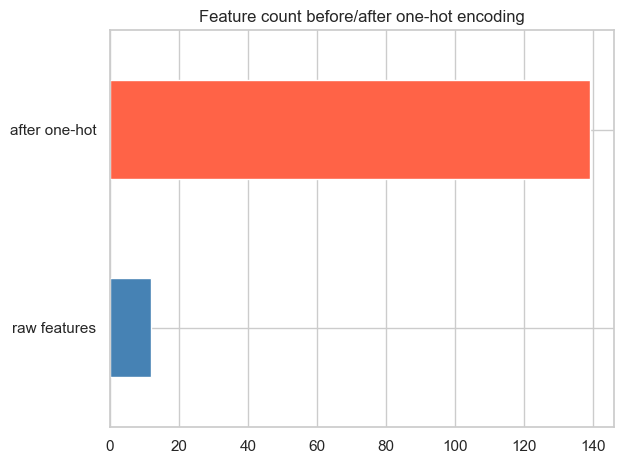

In [3]:
n_rows, n_cols = df.shape
X_wide = pd.get_dummies(df.drop(columns=TARGET), dtype=float)
print(f"Rows: {n_rows} | Columns: {n_cols} (incl. target)")
print(f"Features after one-hot encoding: {X_wide.shape[1]}")
print(f"Rows per raw feature: {n_rows/(n_cols-1):.0f} | rows per encoded feature: {n_rows/X_wide.shape[1]:.0f}")
print(f"Smallest class: {df[TARGET].value_counts().min()} rows")

pd.Series({"raw features": n_cols-1, "after one-hot": X_wide.shape[1]}).plot.barh(color=["steelblue","tomato"])
plt.title("Feature count before/after one-hot encoding"); plt.tight_layout(); plt.show()

## Missing values, dublicates, zeros, impossible values - 1C

In [4]:
print("Total missing values :", int(df.isna().sum().sum()))
print("Complete duplicate rows:", int(df.duplicated().sum()), "(rows that repeat an earlier row)")
display(df[df.duplicated(keep=False)].sort_values(list(df.columns))) # show both copies of each duplicate

print("\nZeros and negatives per numeric column:")
display(pd.DataFrame({"zeros": (df[num_cols] == 0).sum(), "negatives": (df[num_cols] < 0).sum(),
                      "min": df[num_cols].min(), "max": df[num_cols].max()}))

Total missing values : 0
Complete duplicate rows: 2 (rows that repeat an earlier row)


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
886,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
1870,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5



Zeros and negatives per numeric column:


,zeros,negatives,min,max
Age,0,0,18.0,24.0
Avg_Daily_Usage_Hours,0,0,1.0,8.8
Daily_Unlocks,0,0,62.0,273.0
Study_Hours,0,0,0.3,8.3
Physical_Activity_Hours,13,10,-0.4,4.1
Sleep_Hours_Per_Night,0,0,3.6,9.9
Mental_Health_Score,0,0,3.6,9.4


,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level
2277,-0.1,4.7,Very High
2923,-0.1,5.8,Very High
3056,-0.3,5.7,Very High
3422,-0.1,5.8,Very High
3882,-0.2,5.1,Very High
4058,-0.1,7.4,High
4243,-0.4,5.0,Very High
4406,-0.3,4.5,Very High
4522,-0.2,5.7,Very High
4771,-0.2,5.2,Very High


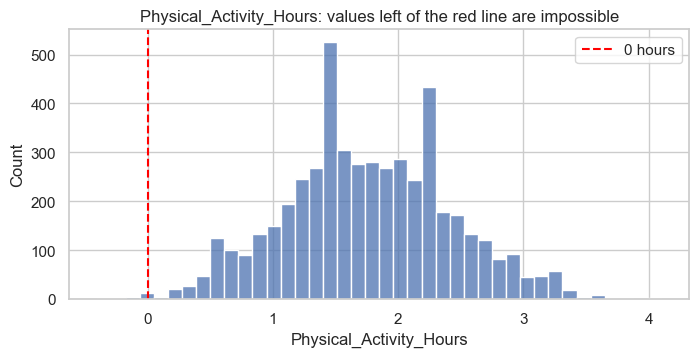

Hours tracked per day: min 12.1 max 22.1 | rows over 24h: 0


,min,max,count
Academic_Level,,,
Graduate,23,24,918
High School,18,18,450
Undergraduate,19,22,3632


Gender: values with stray spaces = 0, distinct = 2
Country: values with stray spaces = 0, distinct = 111
Academic_Level: values with stray spaces = 0, distinct = 3
Most_Used_Platform: values with stray spaces = 0, distinct = 12
Purpose_Of_Use: values with stray spaces = 0, distinct = 4


In [5]:
# the impossible values
display(df[df["Physical_Activity_Hours"] < 0][["Physical_Activity_Hours", "Sleep_Hours_Per_Night", TARGET]])

plt.figure(figsize=(8,3.5))
sns.histplot(df["Physical_Activity_Hours"], bins=40)
plt.axvline(0, color="red", ls="--", label="0 hours"); plt.legend()
plt.title("Physical_Activity_Hours: values left of the red line are impossible"); plt.show()

# plausibility checks
tracked = df[["Avg_Daily_Usage_Hours","Study_Hours","Sleep_Hours_Per_Night","Physical_Activity_Hours"]].sum(axis=1)
print("Hours tracked per day: min", tracked.min().round(1), "max", tracked.max().round(1), "| rows over 24h:", int((tracked > 24).sum()))
display(df.groupby("Academic_Level")["Age"].agg(["min", "max", "count"]))
for col in cat_cols:
    print(f"{col}: values with stray spaces = {(df[col] != df[col].str.strip()).sum()}, distinct = {df[col].nunique()}")

## Alerts from big-picture tools - 1D

In [2]:
import os
os.makedirs("../../reports", exist_ok=True)
try:
    from ydata_profiling import ProfileReport
    profile = ProfileReport(df, title="Student Social Media & Mental Health - preliminary EDA", explorative=True)
    profile.to_file("../../reports/student_ydata_profile.html")
    print("Saved reports/student_ydata_profile.html  -> open it in your browser")
    try:
        alerts = [str(a) for a in profile.get_description().alerts]
        display(pd.DataFrame({"ydata-profiling alert": alerts}))
    except Exception as e:
        print("(Could not list alerts in the notebook - read the 'Alerts' tab in the HTML report.)", e)
except ImportError:
    print("ydata-profiling is not installed.  Run:  pip install ydata-profiling")

ydata-profiling is not installed.  Run:  pip install ydata-profiling


Verification - Personal Notes

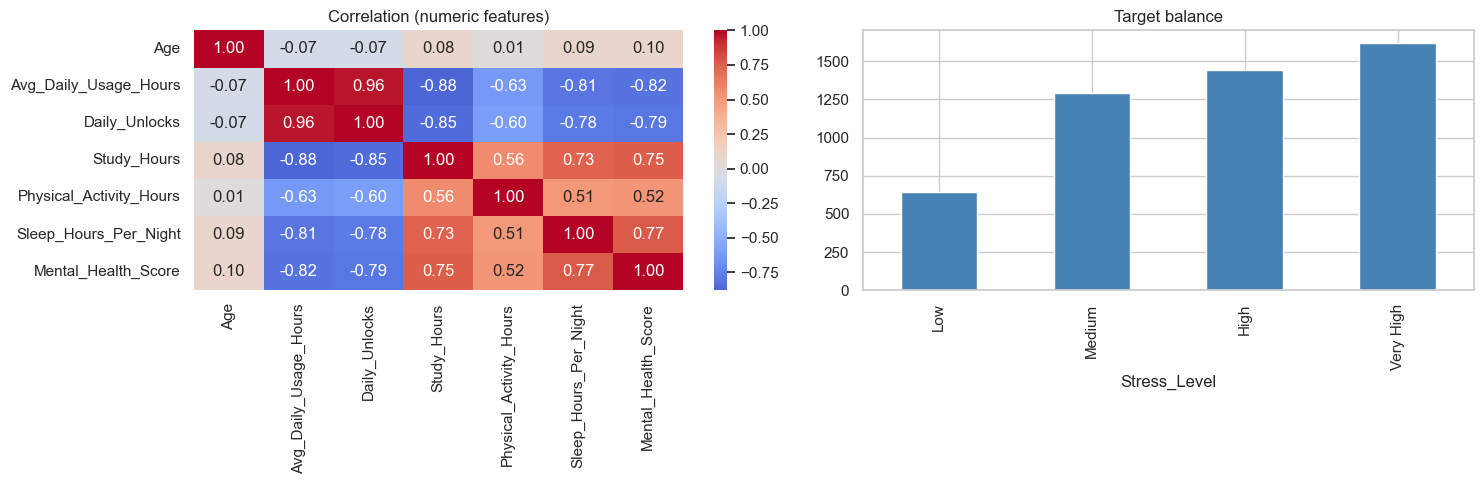

,feature_1,feature_2,abs_corr
0,Avg_Daily_Usage_Hours,Daily_Unlocks,0.960187
1,Avg_Daily_Usage_Hours,Study_Hours,0.878645
2,Daily_Unlocks,Study_Hours,0.853397
3,Avg_Daily_Usage_Hours,Mental_Health_Score,0.816453
4,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,0.808388
5,Daily_Unlocks,Mental_Health_Score,0.790851
6,Daily_Unlocks,Sleep_Hours_Per_Night,0.781823
7,Sleep_Hours_Per_Night,Mental_Health_Score,0.766430
8,Study_Hours,Mental_Health_Score,0.752626
9,Study_Hours,Sleep_Hours_Per_Night,0.730136


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[0]); ax[0].set_title("Correlation (numeric features)")
df[TARGET].value_counts().reindex(ORDER).plot.bar(ax=ax[1], color="steelblue"); ax[1].set_title("Target balance"); plt.tight_layout(); plt.show()
display(high_corr_pairs(df, num_cols, 0.7))